# 🤖 Part 4: 3DOF Kinematics & Jacobian

3자유도(3DOF) 평면 로봇 팔의 정기구학, **야코비안(Jacobian) 행렬**, 그리고 **조작성(Manipulability)** 실습이다.

## 1. 3DOF 평면 로봇의 FK 구현

3자유도 로봇 팔의 말단 좌표 $(x_3, y_3)$ 계산식이다.

$$
x_3 = L_1\cos\theta_1 + L_2\cos(\theta_1+\theta_2) + L_3\cos(\theta_1+\theta_2+\theta_3)
$$
$$
y_3 = L_1\sin\theta_1 + L_2\sin(\theta_1+\theta_2) + L_3\sin(\theta_1+\theta_2+\theta_3)
$$

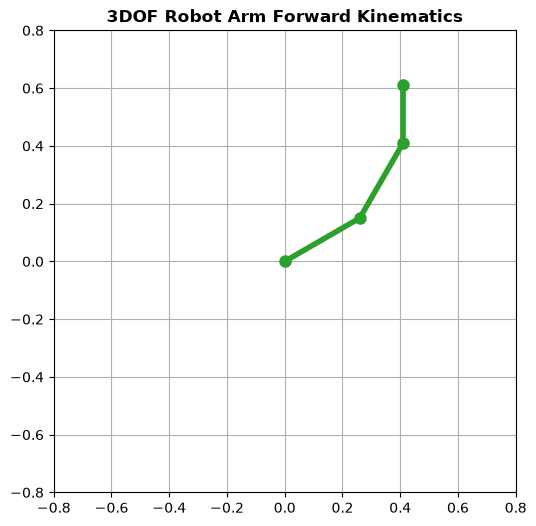

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class RobotArm3DOF:
    def __init__(self, L1=0.3, L2=0.3, L3=0.2):
        self.links = [L1, L2, L3]
        
    def fk(self, thetas):
        """관절 각도 thetas (라디안 array)로부터 0, 1, 2, 3 관절 좌표들 계산"""
        t1, t2, t3 = thetas
        L1, L2, L3 = self.links
        
        p0 = np.array([0.0, 0.0])
        p1 = p0 + np.array([L1 * np.cos(t1), L1 * np.sin(t1)])
        p2 = p1 + np.array([L2 * np.cos(t1 + t2), L2 * np.sin(t1 + t2)])
        p3 = p2 + np.array([L3 * np.cos(t1 + t2 + t3), L3 * np.sin(t1 + t2 + t3)])
        
        return p0, p1, p2, p3

# 예제 1: 3DOF 로봇 팔의 기본 시각화
robot = RobotArm3DOF()
thetas = np.radians([30, 30, 30])
p0, p1, p2, p3 = robot.fk(thetas)

plt.figure(figsize=(6, 6))
plt.plot([p0[0], p1[0], p2[0], p3[0]], [p0[1], p1[1], p2[1], p3[1]], 'o-', color='#2ca02c', lw=4, markersize=8)
plt.xlim(-0.8, 0.8)
plt.ylim(-0.8, 0.8)
plt.grid(True)
plt.gca().set_aspect('equal')
plt.title("3DOF Robot Arm Forward Kinematics", fontsize=12, fontweight='bold')
plt.show()

## 2. 야코비안 (Jacobian): 수치 미분 vs 해석 미분 비교

관절 각속도와 말단 속도 간의 선형 변환 관계를 나타내는 야코비안 행렬($J$)을 두 가지 방식으로 계산하고 교차 검증한다.

$$
dx = J d\theta
$$

In [2]:
def get_numerical_jacobian(robot, thetas, epsilon=1e-6):
    """수치적 편미분을 통한 2x3 야코비안 계산"""
    J = np.zeros((2, 3))
    _, _, _, p3_0 = robot.fk(thetas)
    
    for i in range(3):
        thetas_p = np.array(thetas, dtype=float)
        thetas_p[i] += epsilon
        _, _, _, p3_p = robot.fk(thetas_p)
        J[:, i] = (p3_p - p3_0) / epsilon
    return J

def get_analytical_jacobian(robot, thetas):
    """해석적 미분 공식을 직접 코딩한 2x3 야코비안 계산"""
    t1, t2, t3 = thetas
    L1, L2, L3 = robot.links
    
    # 편미분 계산
    dx_dt1 = -L1*np.sin(t1) - L2*np.sin(t1+t2) - L3*np.sin(t1+t2+t3)
    dx_dt2 = -L2*np.sin(t1+t2) - L3*np.sin(t1+t2+t3)
    dx_dt3 = -L3*np.sin(t1+t2+t3)
    
    dy_dt1 = L1*np.cos(t1) + L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
    dy_dt2 = L2*np.cos(t1+t2) + L3*np.cos(t1+t2+t3)
    dy_dt3 = L3*np.cos(t1+t2+t3)
    
    return np.array([
        [dx_dt1, dx_dt2, dx_dt3],
        [dy_dt1, dy_dt2, dy_dt3]
    ])

# 예제 2: 두 야코비안 비교 검증
thetas_test = np.radians([45, -30, 15])
J_num = get_numerical_jacobian(robot, thetas_test)
J_ana = get_analytical_jacobian(robot, thetas_test)

print("수치적 야코비안:\n", J_num)
print("\n해석적 야코비안:\n", J_ana)
diff = np.linalg.norm(J_num - J_ana)
print(f"\n두 행렬 간 유클리드 거리 차이: {diff:.3e} (오차 1e-6 이하로 검증 완료)")

수치적 야코비안:
 [[-0.38977809 -0.17764595 -0.10000009]
 [ 0.67511467  0.46298274  0.17320503]]

해석적 야코비안:
 [[-0.38977775 -0.17764571 -0.1       ]
 [ 0.67511486  0.46298283  0.17320508]]

두 행렬 간 유클리드 거리 차이: 4.727e-07 (오차 1e-6 이하로 검증 완료)


## 3. 조작성 지수 (Manipulability Index) 시각화

로봇이 특정 포즈에서 임의의 방향으로 말단을 움직일 수 있는 성능의 척도인 조작성($w$) 지수를 시각화한다. $w=0$인 지점은 특정 방향으로 제어가 불가능한 **특이점(Singularity)**이다.

$$
w = \sqrt{\det(J J^T)}
$$

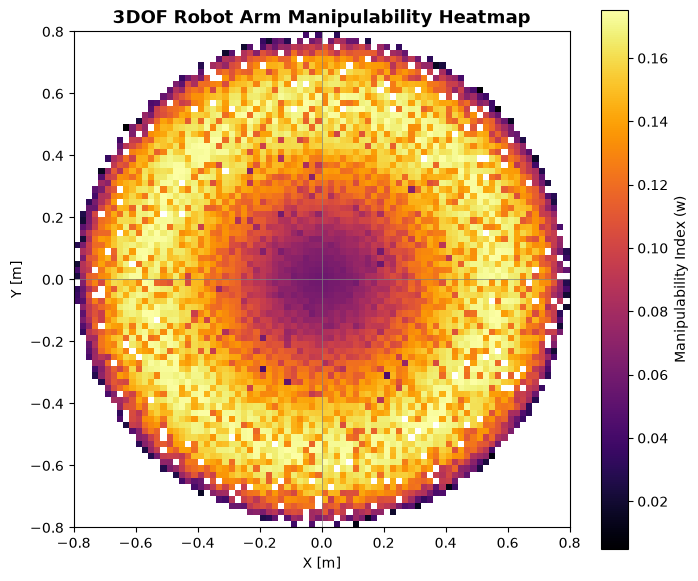

In [3]:
def calc_manipulability(J):
    """w = sqrt(det(J * J^T)) 계산"""
    JJ_T = J @ J.T
    return np.sqrt(np.linalg.det(JJ_T))

# 예제 3: 로봇 작업공간 전체에 걸친 조작성 맵 시각화
x_grid, y_grid = np.meshgrid(np.linspace(-0.8, 0.8, 80), np.linspace(-0.8, 0.8, 80))
manip_map = np.zeros_like(x_grid)
mask = np.zeros_like(x_grid, dtype=bool)

# 몬테카를로를 이용해 각 그리드에 대해 도달가능 포즈의 최대 조작성을 기입
np.random.seed(0)
num_samples = 25000
t1_samples = np.random.uniform(-np.pi, np.pi, num_samples)
t2_samples = np.random.uniform(-np.pi, np.pi, num_samples)
t3_samples = np.random.uniform(-np.pi, np.pi, num_samples)

for t1, t2, t3 in zip(t1_samples, t2_samples, t3_samples):
    _, _, _, p3 = robot.fk([t1, t2, t3])
    # 가장 가까운 그리드 인덱스 매핑
    ix = np.argmin(np.abs(x_grid[0, :] - p3[0]))
    iy = np.argmin(np.abs(y_grid[:, 0] - p3[1]))
    
    J = get_analytical_jacobian(robot, [t1, t2, t3])
    w = calc_manipulability(J)
    
    # 해당 좌표에서 더 큰 조작성 값을 유지
    if w > manip_map[iy, ix]:
        manip_map[iy, ix] = w
        mask[iy, ix] = True

# 시각화
plt.figure(figsize=(8, 7))
manip_map[~mask] = np.nan # 도달불가능 영역은 마스킹
im = plt.imshow(manip_map, extent=[-0.8, 0.8, -0.8, 0.8], origin='lower', cmap='inferno')
plt.colorbar(im, label='Manipulability Index (w)')
plt.axhline(0, color='grey', lw=0.5)
plt.axvline(0, color='grey', lw=0.5)
plt.title("3DOF Robot Arm Manipulability Heatmap", fontsize=13, fontweight='bold')
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.show()